In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos para ficar com visual profissional
sns.set_theme(style="whitegrid")

# 1. Carregando os dados brutos
caminho_dados = '../data/raw/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(caminho_dados)

# 2. Visualizando as primeiras linhas para entender a cara do dataset
display(df.head())

# 3. Resumo técnico (tipos de dados e contagem de linhas)
print("\n--- Informações do Dataset ---")
df.info()

# 4. Verificando os valores nulos (Exigência da Fase 1)
print("\n--- Contagem de Valores Nulos ---")
print(df.isnull().sum())

Matplotlib is building the font cache; this may take a moment.


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

--- Contagem de Valores Nulos ---
id                     0
gender                 0
age                    0
hypertension           0
heart

C:\Users\12407421426\AppData\Local\Temp\ipykernel_1636\248269073.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='stroke', ax=axes[0, 0], palette='Set2')


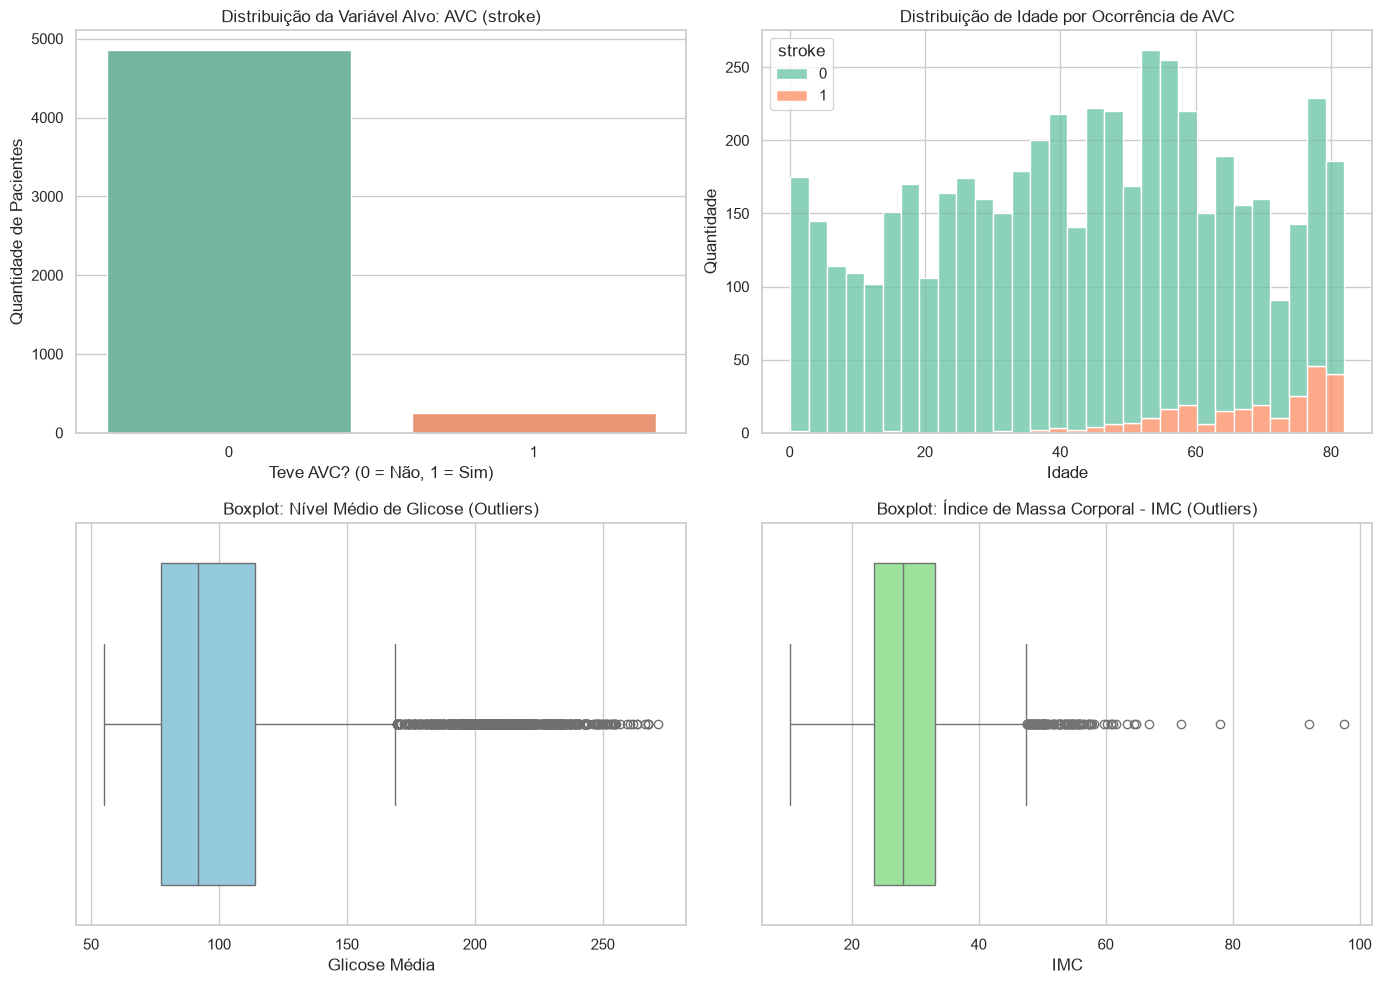

In [2]:
# 1. Removendo a coluna 'id', pois ela não ajuda na predição e atrapalha a análise
df = df.drop('id', axis=1)

# Criando uma figura com espaço para 4 gráficos (2 linhas e 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Gráfico 1: Análise Univariada (O Desbalanceamento) ---
# Mostra a quantidade de pessoas que tiveram AVC vs não tiveram
sns.countplot(data=df, x='stroke', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribuição da Variável Alvo: AVC (stroke)')
axes[0, 0].set_xlabel('Teve AVC? (0 = Não, 1 = Sim)')
axes[0, 0].set_ylabel('Quantidade de Pacientes')

# --- Gráfico 2: Análise Bivariada (Idade vs AVC) ---
# Como a idade se relaciona com a ocorrência de AVC
sns.histplot(data=df, x='age', hue='stroke', multiple='stack', ax=axes[0, 1], palette='Set2', bins=30)
axes[0, 1].set_title('Distribuição de Idade por Ocorrência de AVC')
axes[0, 1].set_xlabel('Idade')
axes[0, 1].set_ylabel('Quantidade')

# --- Gráfico 3: Identificação de Outliers (Nível de Glicose) ---
# O Boxplot é o gráfico perfeito exigido para mostrar pontos fora da curva (outliers)
sns.boxplot(data=df, x='avg_glucose_level', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Boxplot: Nível Médio de Glicose (Outliers)')
axes[1, 0].set_xlabel('Glicose Média')

# --- Gráfico 4: Identificação de Outliers (IMC - bmi) ---
sns.boxplot(data=df, x='bmi', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Boxplot: Índice de Massa Corporal - IMC (Outliers)')
axes[1, 1].set_xlabel('IMC')

# Ajusta o espaçamento para não sobrepor os textos e exibe a imagem
plt.tight_layout()
plt.show()

### Insights da Análise Exploratória (EDA)

Com base nas visualizações acima, podemos extrair as seguintes conclusões para guiar a modelagem:

1. **Desbalanceamento Extremo (Variável Alvo):**
   * O gráfico de distribuição da variável alvo revela que a imensa maioria dos registros pertence à classe negativa (0 - Sem AVC).
   * **Ação para a Fase 2:** O uso de técnicas de balanceamento, como o *Oversampling* (ex: SMOTE), será obrigatório para evitar que o modelo preveja sempre a classe majoritária.

2. **Relação Idade x AVC:**
   * O histograma demonstra uma clara correlação positiva entre a idade e a incidência de AVC. A proporção de casos positivos (1 - Com AVC) aumenta significativamente em faixas etárias mais avançadas (acima de 60 anos).

3. **Presença de Outliers (Glicose e IMC):**
   * Os *boxplots* indicam a presença de inúmeros valores discrepantes (*outliers*) tanto na glicose média quanto no Índice de Massa Corporal (IMC).
   * Como modelos de *Machine Learning* baseados em distância são sensíveis a *outliers*, será necessário aplicar um escalonamento adequado (ex: `RobustScaler` ou `StandardScaler`) durante o *pipeline* de dados.

4. **Tratamento de Dados Nulos:**
   * Conforme identificado anteriormente, a coluna `bmi` (IMC) possui 201 valores nulos.
   * **Ação para a Fase 2:** Esses dados faltantes precisarão ser imputados no *pipeline*. A imputação pela mediana ou média será a estratégia inicial.